# ECSE 415 Course Project: Classification, Detection, and Localization

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import time
import os
import shutil
import random
import torch
import torchvision.models as models
import pandas as pd
import cv2
from pathlib import Path
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn import metrics
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from sklearn.svm import LinearSVC
from skimage.feature import hog

## Part 1: The Classification Benchmark [50 Points]

Path declaration for part 1:

In [2]:
path = './part1/'

In [3]:
# Create split folders if they don't exist
os.makedirs(path + 'train/train_split/cats', exist_ok=True)
os.makedirs(path + 'train/train_split/dogs', exist_ok=True)
os.makedirs(path + 'train/test_split/cats', exist_ok=True)
os.makedirs(path + 'train/test_split/dogs', exist_ok=True)

if len(os.listdir(path + 'train/train_split/cats')) == 0:
    cats = Path(path+'/train/train/cats')
    cat_imgs = list(cats.iterdir())
    dogs = Path(path+'/train/train/dogs')
    dog_imgs = list(dogs.iterdir())

    #shuffle all cat and dog images
    random.shuffle(cat_imgs)
    random.shuffle(dog_imgs)

    #split- first 80% -> training, last 20* of list -> internal testing
    split_cats = int(len(cat_imgs) * 0.8)
    split_dogs = int(len(dog_imgs) * 0.8)
    train_cats = cat_imgs[:split_cats]
    test_cats = cat_imgs[split_cats:]
    train_dogs = dog_imgs[:split_dogs]
    test_dogs = dog_imgs[split_dogs:]

    #use shutil to copy images in each list
    for img in train_cats:
        shutil.copy2(img, path+'train/train_split/cats')
    for img in test_cats:
        shutil.copy2(img, path+'train/test_split/cats')
    for img in train_dogs:
        shutil.copy2(img, path+'train/train_split/dogs')
    for img in test_dogs:
        shutil.copy2(img, path+'train/test_split/dogs')

else:
    print("Split already done, skipping.")


Split already done, skipping.


In [4]:
# Verify split counts
train_cats_count = len(os.listdir(path + 'train/train_split/cats'))
train_dogs_count = len(os.listdir(path + 'train/train_split/dogs'))
test_cats_count = len(os.listdir(path + 'train/test_split/cats'))
test_dogs_count = len(os.listdir(path + 'train/test_split/dogs'))

print(f'Train cats: {train_cats_count}')
print(f'Train dogs: {train_dogs_count}')
print(f'Total train: {train_cats_count + train_dogs_count}')
print(f'Test cats: {test_cats_count}')
print(f'Test dogs: {test_dogs_count}')
print(f'Total test: {test_cats_count + test_dogs_count}')

Train cats: 8016
Train dogs: 7983
Total train: 15999
Test cats: 2005
Test dogs: 1996
Total test: 4001


### 1. Method Selection (Training)

**Option A**:

In [5]:
# Step 1: Defining split directory paths for Option A
optionA_train_catsPath = Path(path + 'train/train_split/cats')
optionA_train_dogsPath = Path(path + 'train/train_split/dogs')
optionA_test_catsPath = Path(path + 'train/test_split/cats')
optionA_test_dogsPath = Path(path + 'train/test_split/dogs')

# Step 2: Setting feature parameters
imgSize = 64
labelNames = ['cat', 'dog']

# This section keeps the aspect ratio, then pads to a square before computing the HOG
# This makes the feature length consistent across all images before classification
def preprocessImage(imagePath, imgSize=64):
    image = cv2.imread(str(imagePath))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    h, w = image.shape
    scale = imgSize / max(h, w)

    newW = int(w * scale)
    newH = int(h * scale)

    resized = cv2.resize(image, (newW, newH))
    padded = np.zeros((imgSize, imgSize), dtype=np.uint8)

    yOffset = (imgSize - newH) // 2
    xOffset = (imgSize - newW) // 2
    padded[yOffset:yOffset + newH, xOffset:xOffset + newW] = resized

    return padded

# The HOG descriptor was implemented following the scikit-image documentation:
# https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog
# I use HOG here because it converts each grayscale image into a gradient-based feature vector
def extractHogFeatures(image):
    return hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

# Here I am building the feature matrix by extracting one HOG vector per image and storing its class label
def buildFeatureMatrix(catDir, dogDir, imgSize=64):
    featureList = []
    labelList = []

    for imagePath in sorted(catDir.iterdir()):
        featureList.append(extractHogFeatures(preprocessImage(imagePath, imgSize)))
        labelList.append(0)

    for imagePath in sorted(dogDir.iterdir()):
        featureList.append(extractHogFeatures(preprocessImage(imagePath, imgSize)))
        labelList.append(1)

    return np.array(featureList), np.array(labelList)

In [6]:
# Step 3: Building the HOG feature matrices for the training and internal test splits
xTrain, yTrain = buildFeatureMatrix(optionA_train_catsPath, optionA_train_dogsPath, imgSize)
xTest, yTest = buildFeatureMatrix(optionA_test_catsPath, optionA_test_dogsPath, imgSize)

print("Option A training feature matrix shape:", xTrain.shape)
print("Option A testing feature matrix shape:", xTest.shape)

Option A training feature matrix shape: (15999, 1764)
Option A testing feature matrix shape: (4001, 1764)


In [7]:
# Step 4: Training the classifier
# I referenced the following LinearSVC documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
# The implemented HOG extracts edge and shape information and the SVM classifies these features by learning a decision boundary between cats and dogs.
classifier = LinearSVC(random_state=42, max_iter=10000)
classifier.fit(xTrain, yTrain)

# Step 5: Evaluating on the internal test split
predictions = classifier.predict(xTest)
accuracy = accuracy_score(yTest, predictions)

print(f'Option A Test Accuracy: {100 * accuracy:.2f}%')

Option A Test Accuracy: 71.76%


**Option B**: PCA + SVM

In [ ]:
# Step 1: Define split directory paths
train_cats_dir = Path(path + 'train/train_split/cats')
train_dogs_dir = Path(path + 'train/train_split/dogs')
test_cats_dir = Path(path + 'train/test_split/cats')
test_dogs_dir = Path(path + 'train/test_split/dogs')
print(len(list(train_cats_dir.iterdir())))
print(len(list(train_dogs_dir.iterdir())))
print(len(list(test_cats_dir.iterdir())))
print(len(list(test_dogs_dir.iterdir())))

# Step 2: Load and preprocess images
# Convert to grayscale, resize to 64x64, flatten into 1D vector
img_size = 64

X_train = []
y_train = []
X_test = []
y_test = []

# Helper function to load images
def load_images(folder, label, image_array, label_array):
    for file_name in os.listdir(folder):
        file_path = folder / file_name
        image = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (img_size, img_size))
        image = image.flatten()

        image_array.append(image)
        label_array.append(label)

# Load training and testing data
load_images(train_cats_dir, 0, X_train, y_train)
load_images(train_dogs_dir, 1, X_train, y_train)
load_images(test_cats_dir, 0, X_test, y_test)
load_images(test_dogs_dir, 1, X_test, y_test)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


8016
7983
2005
1996
Training samples: 15999
Testing samples: 4001


In [ ]:
# Step 3: Apply PCA (reduce dimensionality)
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Reduced number of PCA features:", X_train_pca.shape[1])

Original number of features: 4096
Reduced number of PCA features: 907


In [ ]:
# Step 4: Train SVM classifier
classifier = SVC(kernel='rbf', C=10, gamma='scale')
classifier.fit(X_train_pca, y_train)


# Step 5: Evaluate model on test set
predictions = classifier.predict(X_test_pca)

accuracy = accuracy_score(y_test, predictions)
print(f'Test Accuracy: {100 * accuracy:.2f}%')

Test Accuracy: 65.51%


**Option C**: Fine-Tuned ResNet

In [ ]:
# Step 1: Load pre-trained ResNet-18 and modify the final layer for binary classification
# ResNet-18 is chosen over deeper variants (ResNet-34, ResNet-50) to reduce computational
# cost. Performance gains from deeper architectures are marginal for this binary task. (https://arxiv.org/pdf/1512.03385 )
model = models.resnet50(pretrained=True)
num_classes = 2  # cats and dogs

# Replace the final fully connected layer to output 2 classes instead of ImageNet's 1000.
# in_features is preserved from the original layer.
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# Step 2: Preprocess training and testing data
# Apply data augmentation to training data to improve generalization and reduce overfitting.
# Test data is only transformed through normalization.
# Reference for normalization values: https://pytorch.org/hub/pytorch_vision_resnet/
data_transforms = {
    # Apply data augmentation and normalization to training data
    'train': transforms.Compose([
        # Randomly crop and resize to 224x224 to vary scale and position across epochs
        transforms.RandomResizedCrop(224),
        # Randomly apply horizontal flip- this does not affect the fact that image still looks like a cat, and helps with augmentation
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # Normalize using ImageNet mean and std required for pretrained ResNet weights
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    # Apply just resize+crop and normalization for test set
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = ImageFolder(path+'train/train_split', transform=data_transforms['train'])
test_dataset = ImageFolder(path+'train/test_split', transform=data_transforms['test'])

# Shuffle training data so model sees images in different order at every epoch
# num_workers allows use of 4 cores
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [ ]:
# Step 3: Loss function and optimizer
# Momentum value for optimizer chosen following tutorial: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
# Step 4: Model training

def train_model(model, train_loader, loss_function, optimizer, num_epochs):
    # Detect whether we can use GPU, or else use CPU
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Move model's weights/parameters to GPU memory, if available
    model = model.to(device)

    since = time.time()
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        total_loss = 0.0
        correct = 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            # Move inputs and labels to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Reset the gradients to zero
            optimizer.zero_grad()
            # Forward pass
            predictions = model(inputs)
            _, predicted_classes = torch.max(predictions, dim=1)
            # Calculate loss
            loss = loss_function(predictions, labels)
            total_loss += loss.item() * inputs.size(0)
            # Backpropagation
            loss.backward()
            # Update weights
            optimizer.step()
            # Get cumulative correct predictions
            correct += torch.sum(predicted_classes == labels.data)

        # Calculate avg training loss and accuracy for epoch
        training_loss = total_loss/len(train_loader.dataset)
        training_accuracy = correct.float() / len(train_loader.dataset)
        print(f'Train loss: {training_loss:.4f}, train acc: {training_accuracy:.4f}')
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    return model

# Train the model
model = train_model(model, train_loader, loss_function, optimizer, num_epochs=10)

# Save the trained model weights
torch.save(model.state_dict(), 'resnet50.pth')

Using device: mps
Epoch 1/10
--------------------


Epoch 1/10: 100%|██████████| 625/625 [05:33<00:00,  1.87it/s]


Train loss: 0.1247, train acc: 0.9498
Epoch 2/10
--------------------


Epoch 2/10: 100%|██████████| 625/625 [05:41<00:00,  1.83it/s]


Train loss: 0.0814, train acc: 0.9663
Epoch 3/10
--------------------


...

Train loss: 0.0510, train acc: 0.9796
Epoch 9/10
--------------------


Epoch 9/10: 100%|██████████| 625/625 [05:33<00:00,  1.88it/s]


Train loss: 0.0463, train acc: 0.9818
Epoch 10/10
--------------------


Epoch 10/10: 100%|██████████| 625/625 [05:42<00:00,  1.82it/s]


Train loss: 0.0497, train acc: 0.9792
Training complete in 56m 38s


In [ ]:
# Evaluate model on test set
model.eval()

correct = 0
total = 0
# Used for confusion matrix
ResNet_preds = []
true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        # Collect predictions and true labels
        ResNet_preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 99.88%


In [5]:
# Load saved model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('resnet50.pth'))
model.eval()
model = model.to(device)

/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


(Not part of project): Testing model on personal pet images

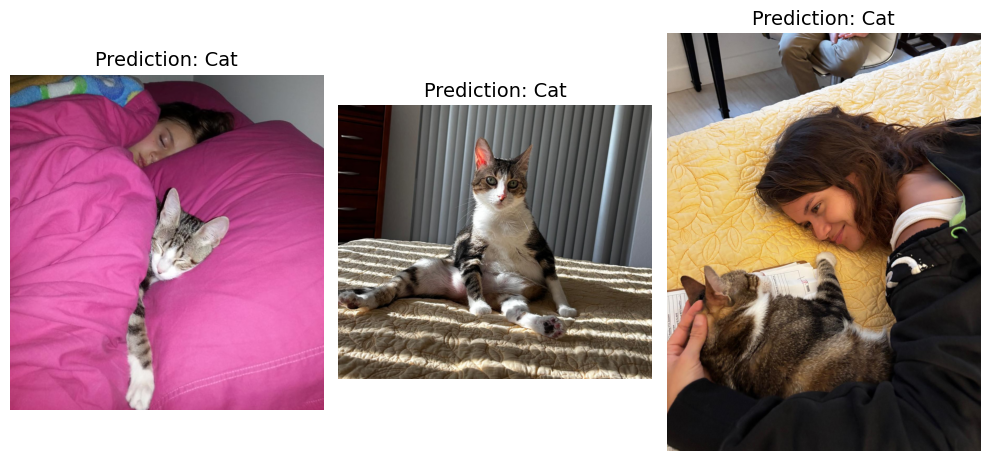

In [9]:
image_paths = ['lilly1.JPG', 'lilly2.JPG', 'lilly3.JPG'] 

model.eval()
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, img_path in zip(axes, image_paths):
    # Load and preprocess
    image = Image.open(img_path)
    tensor = data_transforms['test'](image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(tensor)
        _, pred = torch.max(output, 1)
    
    label = 'Dog' if pred.item() == 1 else 'Cat'
    
    # Display
    ax.imshow(image)
    ax.set_title(f'Prediction: {label}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
kaggle_test_images = Path(path + 'test/test/').iterdir()
ids = []
predictions = []

for img_path in kaggle_test_images:
    image = Image.open(img_path)
    image = data_transforms['test'](image)
    image = image.unsqueeze(0)
    image = image.to(device)
    id = img_path.stem
    with torch.no_grad():
        output = model(image)
        _, prediction = torch.max(output, 1)
    ids.append(id)
    predictions.append(prediction.item())

df = pd.DataFrame({'id': ids, 'label': predictions})
df.to_csv('submission.csv', index=False)

### 2. Local Analysis and Evaluation

A. HOG + Linear SVM Confusion matrix

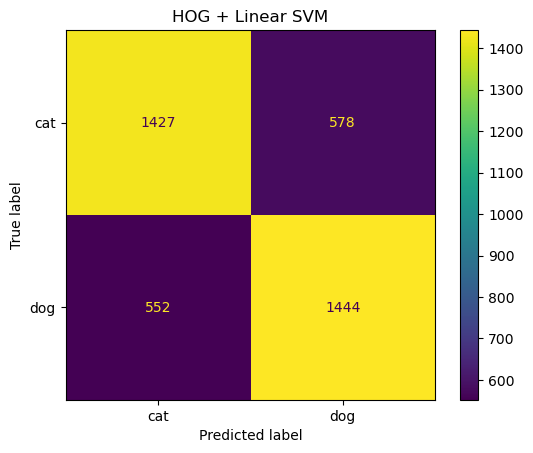

In [8]:
cm = confusion_matrix(yTest, predictions)
cmDisplay = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelNames)
cmDisplay.plot()
plt.title('HOG + Linear SVM')
plt.show()

B. PCA + SVM Confusion matrix

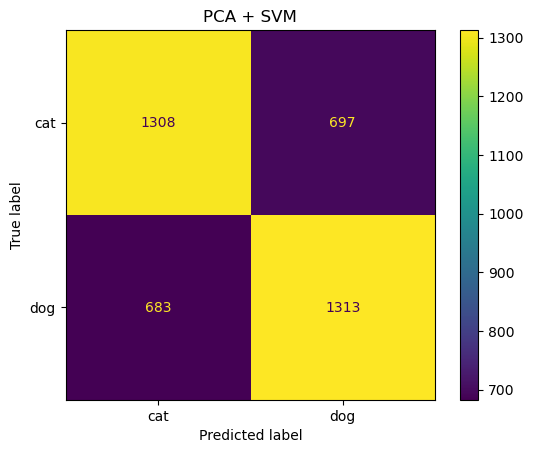

In [ ]:
cm = confusion_matrix(y_test, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
cm_display.plot()
plt.title('PCA + SVM')
plt.show()

C. ResNet-50 Confusion matrix

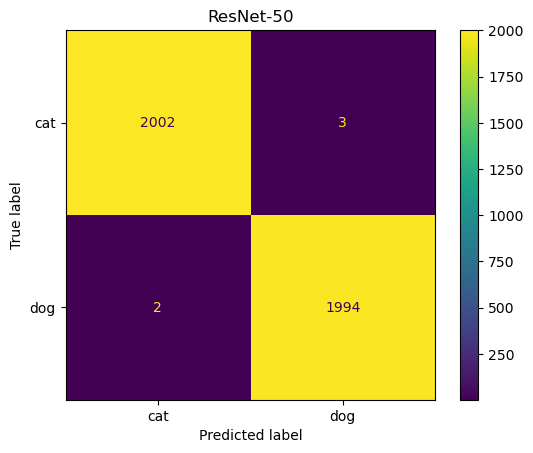

In [ ]:
confusion_matrix = metrics.confusion_matrix(true_labels, ResNet_preds)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["cat", "dog"])
cm_display.plot()
plt.title('ResNet-50')
plt.show()

## Part 2: Detection and Localization [50 Points]

In [ ]:
path = './part2/'